# Mortgage Exposure at Default (EAD) Model

## Business Objective
Estimate **Exposure at Default (EAD)** for an individual mortgage that reaches serious delinquency/default.

- **Target:** `ead_at_default`
- **Unit of prediction:** Individual mortgage
- **Problem type:** Regression
- **Modeling population:** Mortgages that reached serious delinquency/default
- **Prediction point:** Immediately before first default

**Business use:** support credit-risk measurement, expected-loss estimation, and monitoring of higher-exposure mortgages.

The model complements Mortgage PD:
- **PD:** How likely is the mortgage to default?
- **EAD:** If the mortgage defaults, how much principal exposure will the lender have?


## 1. Setup and Data Loading


In [34]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "freddie_mac"
    / "2018"
    / "mortgage_ead_analytical.csv"
)

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Number of mortgages: {df.shape[0]:,}")


Dataset shape: (2708, 52)
Number of mortgages: 2,708


## 2. Target Analysis


EAD Target Summary
----------------------------------------
Missing EAD values: 0
Zero EAD values: 4
Negative EAD values: 0


count     2,708.00
mean    222,870.13
std     126,114.71
min           0.00
25%     127,554.72
50%     194,971.57
75%     299,278.43
max     707,027.47
Name: ead_at_default, dtype: float64

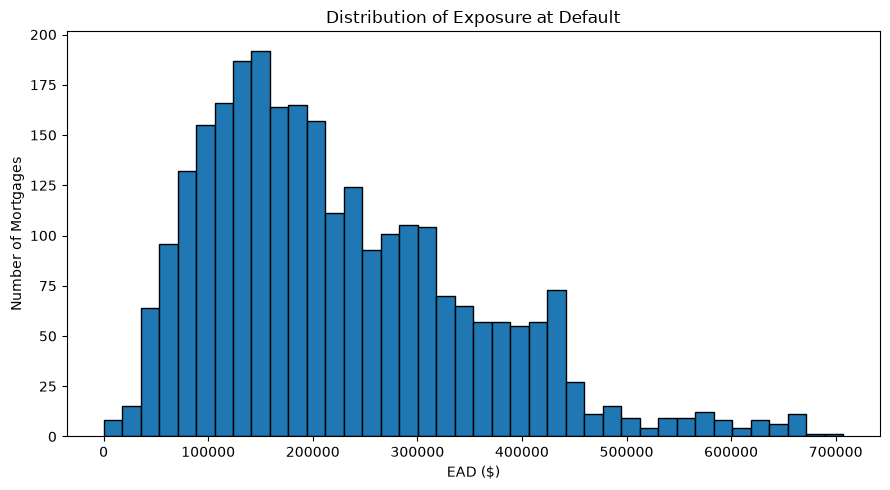

In [35]:
target = "ead_at_default"

print("EAD Target Summary")
print("-" * 40)
print(f"Missing EAD values: {df[target].isna().sum():,}")
print(f"Zero EAD values: {(df[target] == 0).sum():,}")
print(f"Negative EAD values: {(df[target] < 0).sum():,}")
display(df[target].describe())

plt.figure(figsize=(9, 5))
plt.hist(df[target].dropna(), bins=40, edgecolor="black")
plt.title("Distribution of Exposure at Default")
plt.xlabel("EAD ($)")
plt.ylabel("Number of Mortgages")
plt.tight_layout()
plt.show()


The EAD target is complete and non-negative. Its distribution contains an upper tail, but remains suitable for regression modeling.


## 3. Data Quality and Cleaning


In [36]:
# Data-quality checks
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})
missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values("missing_pct", ascending=False)

print(f"Duplicate rows: {df.duplicated().sum():,}")
print(f"Duplicated loan IDs: {df['loan_sequence_number'].duplicated().sum():,}")
display(missing_summary.head(10))

# Replace Freddie Mac special missing-value codes
special_code_map = {
    "credit_score": [9999],
    "original_dti": [999],
    "pre_default_estimated_ltv": [999],
}

for column, codes in special_code_map.items():
    df[column] = df[column].replace(codes, np.nan)

# Remove highly sparse or constant variables
features_to_drop = [
    "mi_cancellation_indicator",
    "super_conforming_flag",
    "pre_harp_loan_sequence_number",
    "ppm_flag",
    "amortization_type",
    "property_valuation_method",
    "interest_only_indicator",
    "default_event",
]

df = df.drop(columns=features_to_drop, errors="ignore")

print(f"Cleaned dataset shape: {df.shape}")


Duplicate rows: 0
Duplicated loan IDs: 0


,missing_count,missing_pct
mi_cancellation_indicator,2708,100.00
super_conforming_flag,2649,97.82
pre_harp_loan_sequence_number,2156,79.62
msa,261,9.64


Cleaned dataset shape: (2708, 44)


Key cleaning decisions:
- no duplicate mortgage records were identified;
- Freddie Mac special codes were converted to missing values;
- highly sparse and constant variables were removed;
- default-period variables and direct balance measures are excluded from the ML feature set to avoid leakage or a near-deterministic prediction problem.


## 4. Feature Selection


In [37]:
# Candidate features used to assess target and predictor correlations
candidate_numeric_features = [
    "credit_score",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "pre_default_loan_age",
    "pre_default_remaining_months_to_maturity",
    "pre_default_current_interest_rate",
    "pre_default_current_loan_delinquency_status",
    "pre_default_estimated_ltv",
]

correlation_matrix = df[candidate_numeric_features + [target]].corr()

ead_correlations = (
    correlation_matrix[target]
    .drop(target)
    .sort_values(key=abs, ascending=False)
)

print("Numerical Feature Correlation with EAD")
print("-" * 45)
print(ead_correlations)

print(
    "\nOriginal vs pre-default interest-rate correlation:",
    f"{correlation_matrix.loc['original_interest_rate', 'pre_default_current_interest_rate']:.3f}"
)


Numerical Feature Correlation with EAD
---------------------------------------------
original_upb                                   0.99
pre_default_estimated_ltv                      0.25
pre_default_remaining_months_to_maturity       0.24
pre_default_loan_age                          -0.19
original_dti                                   0.14
credit_score                                   0.09
pre_default_current_interest_rate             -0.08
original_interest_rate                        -0.08
original_ltv                                   0.05
pre_default_current_loan_delinquency_status    0.04
Name: ead_at_default, dtype: float64

Original vs pre-default interest-rate correlation: 1.000


`original_upb` is strongly associated with EAD and is retained because it is known at origination and represents the initial scale of exposure. `pre_default_current_interest_rate` is removed because it is effectively redundant with `original_interest_rate`.

`pre_default_current_actual_upb` and `pre_default_interest_bearing_upb` are not ML predictors. The former is retained only as the operational benchmark because it is almost identical to EAD immediately before default.


In [38]:
numeric_features = [
    "credit_score",
    "original_dti",
    "original_upb",
    "original_ltv",
    "original_interest_rate",
    "pre_default_loan_age",
    "pre_default_remaining_months_to_maturity",
    "pre_default_current_loan_delinquency_status",
    "pre_default_estimated_ltv",
]

categorical_features = [
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "property_type",
    "loan_purpose",
]

selected_features = numeric_features + categorical_features

X = df[selected_features].copy()
y = df[target].copy()

print(f"Selected predictors: {len(selected_features)}")
print(f"Modeling dataset: {X.shape}")


Selected predictors: 14
Modeling dataset: (2708, 14)


### **Business Feature Definitions**

| Variable                                          | Business definition                                                                                                                                     |
| ------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **credit_score**                                | Borrower's credit score at mortgage origination, representing their assessed creditworthiness and historical ability to meet financial obligations.     |
| **original_dti**                                | Debt-to-Income Ratio at origination.Percentage of the borrower's income committed to debt obligations, used as an indicator of repayment capacity. |
| **original_upb**                                | Original Unpaid Principal Balance. Principal amount of the mortgage when it was originated, representing the initial lender exposure.               |
| **original_ltv**                                | Original Loan-to-Value Ratio. Original mortgage balance relative to the property's value. It represents the initial leverage of the mortgage.       |
| **original_interest_rate**                      | Interest rate charged on the mortgage at origination. It represents the contractual cost of borrowing.                                                  |
| **pre_default_loan_age**                        | Number of months the mortgage has been active immediately before the first default event.                                                               |
| **pre_default_remaining_months_to_maturity**    | Number of contractual months remaining until the mortgage reaches maturity, measured immediately before default.                                        |
| **pre_default_current_loan_delinquency_status** | Payment delinquency status immediately before default, representing how far behind the borrower was on scheduled payments.                              |
| **pre_default_estimated_ltv**                   | Estimated Loan-to-Value ratio immediately before default, representing the mortgage's more recent leverage relative to the estimated property value.    |
| **first_time_homebuyer_flag**                   | Indicates whether the borrower was identified as a first-time homebuyer at origination.                                                                 |
| **occupancy_status**                            | Indicates how the financed property is used, such as a primary residence, second home, or investment property.                                          |
| **channel**                                     | Mortgage origination channel through which the loan was acquired, such as retail, broker, or correspondent channels.                                    |
| **property_type**                               | Type of property securing the mortgage, such as a single-family property, condominium, or manufactured home.                                            |
| **loan_purpose**                                | Purpose for which the mortgage was originated, such as property purchase, cash-out refinance, or no-cash-out refinance.                                 |

**Benchmark**
| Variable                             | Business definition                                                                                                                                                                                |
| ------------------------------------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **pre_default_current_actual_upb** | Pre-default Current Actual Unpaid Principal Balance: Amount of mortgage principal still owed by the borrower immediately before the first default event. It excludes future interest payments. |

**Target Variable**
| Variable             | Business definition                                                                                                                                   |
| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ead_at_default** | xposure at Default (EAD): Outstanding mortgage principal exposure when the mortgage first reaches the defined serious-delinquency/default event. |


## 5. Train/Test Split and Preprocessing


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

# Align the operational benchmark with the test observations
benchmark_test = df.loc[
    X_test.index,
    "pre_default_current_actual_upb"
].copy()

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training mean EAD: ${y_train.mean():,.2f}")
print(f"Test mean EAD: ${y_test.mean():,.2f}")


Training set: (2166, 14)
Test set: (542, 14)
Training mean EAD: $221,308.28
Test mean EAD: $229,111.77


In [40]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first")),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features),
])


## 6. Operational Benchmark


In [41]:
# Benchmark rule: predicted EAD = outstanding principal immediately before default
y_pred_benchmark = benchmark_test.to_numpy()

benchmark_mae = mean_absolute_error(y_test, y_pred_benchmark)
benchmark_rmse = np.sqrt(mean_squared_error(y_test, y_pred_benchmark))
benchmark_r2 = r2_score(y_test, y_pred_benchmark)

print("Pre-Default UPB Benchmark")
print("-" * 40)
print(f"MAE:  ${benchmark_mae:,.2f}")
print(f"RMSE: ${benchmark_rmse:,.2f}")
print(f"R²:    {benchmark_r2:.4f}")


Pre-Default UPB Benchmark
----------------------------------------
MAE:  $421.84
RMSE: $9,269.83
R²:    0.9948


The pre-default UPB benchmark is intentionally strong because the outstanding principal immediately before default is nearly identical to EAD. It establishes the operational performance level against which the ML models are compared.


## 7. Ridge Regression Baseline


In [42]:
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0)),
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print("-" * 40)
print(f"MAE:  ${ridge_mae:,.2f}")
print(f"RMSE: ${ridge_rmse:,.2f}")
print(f"R²:    {ridge_r2:.4f}")
print(f"Negative predictions: {(y_pred_ridge < 0).sum():,}")


Ridge Regression
----------------------------------------
MAE:  $4,610.01
RMSE: $16,125.10
R²:    0.9844
Negative predictions: 0


## 8. HistGradientBoosting Challenger


In [43]:
# HistGradientBoosting requires dense encoded input and does not require scaling
hgb_preprocessor = ColumnTransformer([
    (
        "numeric",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]),
        numeric_features,
    ),
    (
        "categorical",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False,
            )),
        ]),
        categorical_features,
    ),
])

hgb_model = Pipeline([
    ("preprocessor", hgb_preprocessor),
    ("regressor", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=200,
        max_leaf_nodes=15,
        l2_regularization=1.0,
        random_state=42,
    )),
])

hgb_model.fit(X_train, y_train)
y_pred_hgb = hgb_model.predict(X_test)

hgb_mae = mean_absolute_error(y_test, y_pred_hgb)
hgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_hgb))
hgb_r2 = r2_score(y_test, y_pred_hgb)

print("HistGradientBoosting")
print("-" * 40)
print(f"MAE:  ${hgb_mae:,.2f}")
print(f"RMSE: ${hgb_rmse:,.2f}")
print(f"R²:    {hgb_r2:.4f}")


HistGradientBoosting
----------------------------------------
MAE:  $4,416.99
RMSE: $16,376.16
R²:    0.9839


## 9. Model Comparison


In [44]:
model_comparison = pd.DataFrame({
    "Model": [
        "Pre-Default UPB Benchmark",
        "Ridge Regression",
        "HistGradientBoosting",
    ],
    "MAE": [benchmark_mae, ridge_mae, hgb_mae],
    "RMSE": [benchmark_rmse, ridge_rmse, hgb_rmse],
    "R2": [benchmark_r2, ridge_r2, hgb_r2],
})

display(
    model_comparison.style.format({
        "MAE": "${:,.2f}",
        "RMSE": "${:,.2f}",
        "R2": "{:.4f}",
    })
)


,Model,MAE,RMSE,R2
0,Pre-Default UPB Benchmark,$421.84,"$9,269.83",0.9948
1,Ridge Regression,"$4,610.01","$16,125.10",0.9844
2,HistGradientBoosting,"$4,416.99","$16,376.16",0.9839


HistGradientBoosting slightly reduces MAE, while Ridge produces a lower RMSE and slightly higher R². The nonlinear challenger therefore provides limited incremental value.

**Ridge Regression is selected** because it offers comparable predictive performance with greater simplicity, interpretability, and computational efficiency. The pre-default UPB benchmark remains the most accurate operational estimator.


## 10. Lightweight Ridge Diagnostic


Mean residual: $26.65
Median residual: $1,153.32
Median absolute error: $2,615.79
95th percentile absolute error: $10,105.20
Maximum absolute error: $273,722.91


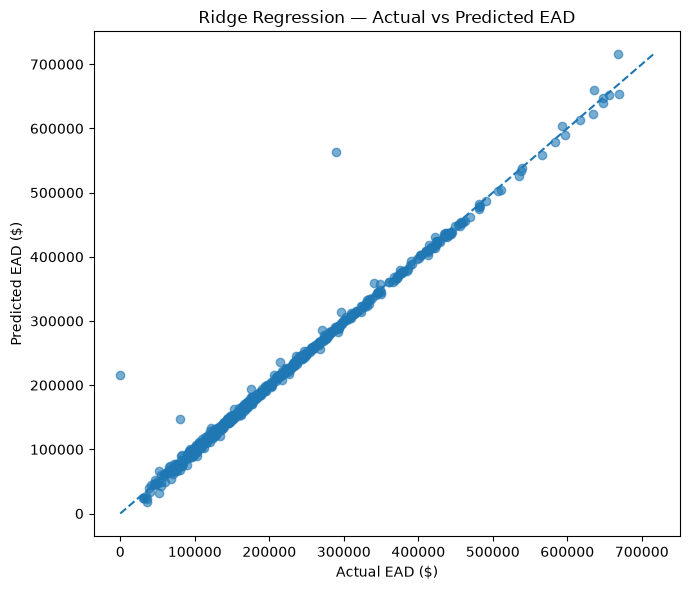

In [45]:
ridge_diagnostics = pd.DataFrame({
    "actual_ead": y_test.to_numpy(),
    "predicted_ead": y_pred_ridge,
})

ridge_diagnostics["residual"] = (
    ridge_diagnostics["actual_ead"]
    - ridge_diagnostics["predicted_ead"]
)
ridge_diagnostics["absolute_error"] = ridge_diagnostics["residual"].abs()

print(f"Mean residual: ${ridge_diagnostics['residual'].mean():,.2f}")
print(f"Median residual: ${ridge_diagnostics['residual'].median():,.2f}")
print(f"Median absolute error: ${ridge_diagnostics['absolute_error'].median():,.2f}")
print(
    "95th percentile absolute error: "
    f"${ridge_diagnostics['absolute_error'].quantile(0.95):,.2f}"
)
print(f"Maximum absolute error: ${ridge_diagnostics['absolute_error'].max():,.2f}")

plt.figure(figsize=(7, 6))
plt.scatter(
    ridge_diagnostics["actual_ead"],
    ridge_diagnostics["predicted_ead"],
    alpha=0.6,
)

min_value = min(
    ridge_diagnostics["actual_ead"].min(),
    ridge_diagnostics["predicted_ead"].min(),
)
max_value = max(
    ridge_diagnostics["actual_ead"].max(),
    ridge_diagnostics["predicted_ead"].max(),
)

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.xlabel("Actual EAD ($)")
plt.ylabel("Predicted EAD ($)")
plt.title("Ridge Regression — Actual vs Predicted EAD")
plt.tight_layout()
plt.show()


Predictions closely align with actual EAD across most mortgages. The near-zero mean residual indicates minimal overall bias. A small number of large errors contribute to the higher RMSE.

Further hyperparameter tuning, outlier analysis, additional Freddie Mac vintages, and broader model experimentation are retained as future improvements.


## 11. Save and Validate Final Model


In [46]:
artifact_path = (
    PROJECT_ROOT
    / "models"
    / "artifacts"
    / "mortgage_ead_regressor_v1.joblib"
)
artifact_path.parent.mkdir(parents=True, exist_ok=True)

ead_artifact = {
    "model": ridge_model,
    "model_name": "mortgage_ead_regressor_v1",
    "model_type": "Ridge Regression",
    "target": target,
    "features": selected_features,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "metrics": {
        "mae": ridge_mae,
        "rmse": ridge_rmse,
        "r2": ridge_r2,
    },
    "benchmark": {
        "name": "Pre-Default UPB Benchmark",
        "variable": "pre_default_current_actual_upb",
        "mae": benchmark_mae,
        "rmse": benchmark_rmse,
        "r2": benchmark_r2,
    },
    "prediction_unit": "Individual mortgage",
    "prediction_point": "Immediately before first serious delinquency/default",
    "target_definition": (
        "Outstanding mortgage principal exposure at the first "
        "serious delinquency/default event."
    ),
}

joblib.dump(ead_artifact, artifact_path)
print(f"Artifact saved successfully: {artifact_path}")


Artifact saved successfully: c:\Users\guima\OneDrive\Documents\AI_project\banking_services_ai_assistant\models\artifacts\mortgage_ead_regressor_v1.joblib


In [47]:
loaded_artifact = joblib.load(artifact_path)
loaded_model = loaded_artifact["model"]

sample_mortgage = X_test.iloc[[0]]
predicted_ead = loaded_model.predict(sample_mortgage)[0]

print(f"Model: {loaded_artifact['model_name']}")
print(f"Predicted EAD: ${predicted_ead:,.2f}")
print(f"Actual EAD:    ${y_test.iloc[0]:,.2f}")
print(f"Number of features: {len(loaded_artifact['features'])}")
print(f"MAE:  ${loaded_artifact['metrics']['mae']:,.2f}")
print(f"RMSE: ${loaded_artifact['metrics']['rmse']:,.2f}")
print(f"R²:    {loaded_artifact['metrics']['r2']:.4f}")


Model: mortgage_ead_regressor_v1
Predicted EAD: $103,425.47
Actual EAD:    $107,469.71
Number of features: 14
MAE:  $4,610.01
RMSE: $16,125.10
R²:    0.9844


## EAD Model Development Process

1. Define the business objective and EAD target.
2. Assess target distribution and data quality.
3. Clean special codes and remove unsuitable variables.
4. Assess leakage and select 14 predictors.
5. Split the data and build preprocessing pipelines.
6. Establish the pre-default UPB operational benchmark.
7. Train Ridge Regression as the baseline.
8. Train HistGradientBoosting as the nonlinear challenger.
9. Compare model performance and perform a lightweight diagnostic.
10. Select Ridge Regression based on performance, simplicity, and interpretability.
11. Save and reload `mortgage_ead_regressor_v1.joblib` to validate the inference pipeline.
